<h1>Debug DLWP Instability</h1>

First lets open the 40 year forecast with our current land model (stable) and gt-ocean coupling. 

In [2]:
import xarray as xr 
import numpy as np 
import pandas as pd
from matplotlib import pyplot as plt 

In [30]:
t2m = xr.open_dataset('/pscratch/sd/n/nacc/veggie-dltm/v4/models/dltm-gt+dlom-gt+rmse_atmos_sm-v4_precip_pm/forecasts/atmos_forecast-coupled_historical_2001.01.01-2005.12.30.nc').t2m
global_mean = t2m.mean(dim=('face', 'height', 'width')).isel(time=0)


In [38]:
valid_time = (global_mean.time.values + global_mean.step.values)

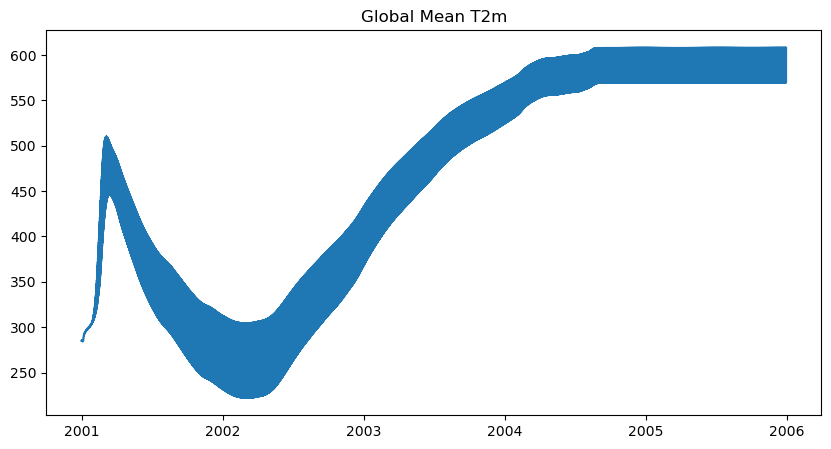

In [42]:
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(valid_time, global_mean)
ax.set_title('Global Mean T2m')
plt.show()




Let's look at the first year

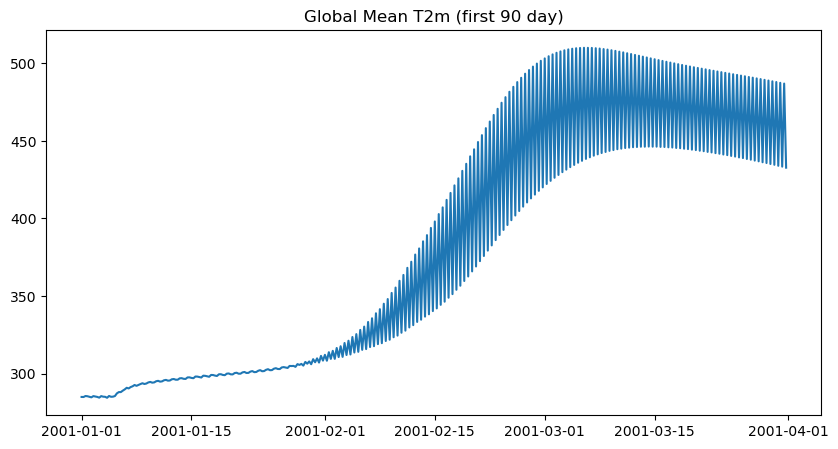

In [45]:
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(valid_time[0:90*4], global_mean[0:90*4])
ax.set_title('Global Mean T2m (first 90 day)')
plt.show()

OK I think I fixed an error in the constant coupler `set_coupled_fields` method. Here's the code block: 

```python
        # we use a constant set of values so we just copy time 0
        for i in range(len(self.preset_coupled_fields)):

            # previous version was broadcasting channel dimension in coupled fields
            # self.preset_coupled_fields[i, :, :, :, :, :] = coupled_fields[
            #     0, :, -1:, :, :, :
            # ]
            self.preset_coupled_fields[i, :, :, :, :, :] = coupled_fields[
                0, :, :, :, :, :
            ]

```

In this loop the orignial assignment (now commented-out) indexs `-1:` in the channel dimension which broadcasts all the coupled channels. In the case of the atmosphere coupled inputs this means that swvl1 will be given in place of sst. 

I ran a 10 year simulation with this fixed. Let's check the t2m from that run.

In [3]:
t2m = xr.open_dataset('/pscratch/sd/n/nacc/veggie-dltm/v4/models/dltm-gt+rmse_atmos_sm-v4_precip_pm+dlom-gt/forecasts/atmos_forecast-coupled_historical_2001.01.01-2011.01.01.nc').t2m
global_mean = t2m.mean(dim=('face', 'height', 'width')).isel(time=0)

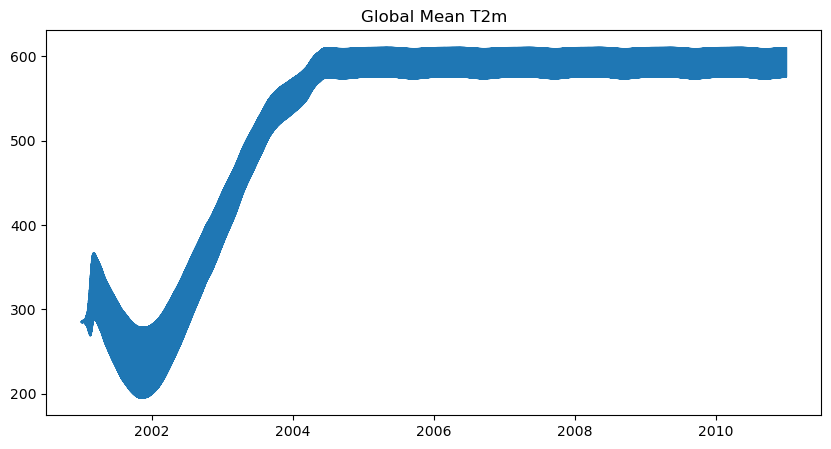

In [4]:
valid_time = (global_mean.time.values + global_mean.step.values)
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(valid_time, global_mean)
ax.set_title('Global Mean T2m')
plt.show()

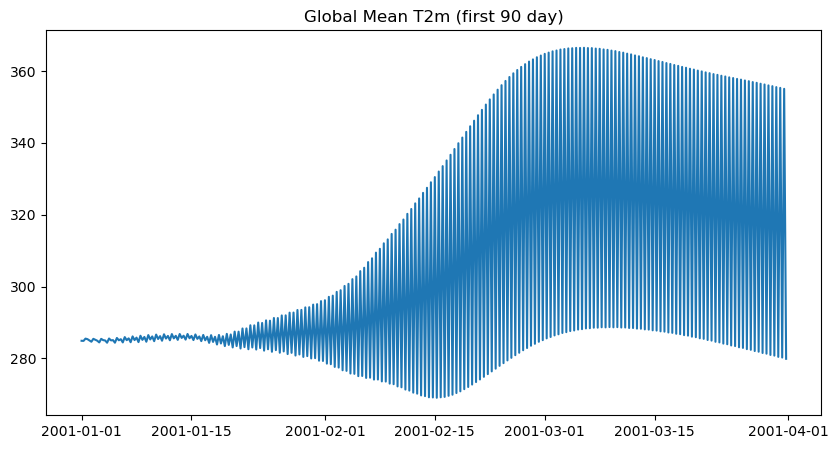

In [5]:
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(valid_time[0:90*4], global_mean[0:90*4])
ax.set_title('Global Mean T2m (first 90 day)')
plt.show()